In [27]:
#=====================================
#
# Model/Data Drift Detection System
#
# MLOps Project
#
# Pablo Rodriguez
#
#
#

In [28]:
from pathlib import Path
from datetime import datetime, timezone
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42

ALPHA = 0.05
ACCURACY_DROP_LIMIT = 0.05
CONFIDENCE_DROP_LIMIT = 0.05
PREDICTION_RATE_CHANGE_LIMIT = 0.10

ARTIFACT_DIR = Path("drift_monitor_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

In [29]:
X, y = make_classification(
    n_samples=5000,
    n_features=8,
    n_informative=6,
    n_redundant=2,
    class_sep=1.5,
    random_state=RANDOM_STATE
)

FEATURES = [
    f"feature_{i}"
    for i in range(X.shape[1])
]

X = pd.DataFrame(
    X,
    columns=FEATURES
)

y = pd.Series(
    y,
    name="target"
)

print("Dataset:", X.shape)
X.head()

Dataset: (5000, 8)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7
0,-1.624299,3.363177,-0.169772,0.383840,-0.901504,0.600345,0.094023,3.096718
1,-4.203242,0.604106,-2.257328,3.384811,-1.383836,-2.189698,-6.638557,3.947618
2,0.927019,2.325710,-0.890768,2.233426,-1.884281,-1.515646,-3.224433,1.450989
3,1.177229,-3.672010,-0.636134,-0.497544,-2.472556,-0.044433,-4.670273,-0.247579
4,-0.053947,0.398781,3.970128,-5.833340,-1.292979,3.619031,5.858204,-0.639039


In [30]:
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y
)

X_reference, X_production, y_reference, y_production = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_remaining
)

print("Training:", len(X_train))
print("Reference:", len(X_reference))
print("Production:", len(X_production))

Training: 3000
Reference: 1000
Production: 1000


In [31]:
model = RandomForestClassifier(
    n_estimators=150,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Production model trained.")

Production model trained.


In [32]:
def score_batch(model, X, y=None):

    predictions = model.predict(X)

    probabilities = model.predict_proba(X)

    confidence = probabilities.max(
        axis=1
    )

    result = {
        "predictions": predictions,
        "confidence": confidence
    }

    if y is not None:
        result["accuracy"] = accuracy_score(
            y,
            predictions
        )

    return result

In [33]:
reference_metrics = score_batch(
    model,
    X_reference,
    y_reference
)

reference_accuracy = (
    reference_metrics["accuracy"]
)

reference_confidence = (
    reference_metrics["confidence"].mean()
)

reference_positive_rate = (
    reference_metrics["predictions"].mean()
)

print(
    f"Reference accuracy: "
    f"{reference_accuracy:.2%}"
)

print(
    f"Reference confidence: "
    f"{reference_confidence:.2%}"
)

print(
    f"Reference positive rate: "
    f"{reference_positive_rate:.2%}"
)

Reference accuracy: 97.60%
Reference confidence: 91.93%
Reference positive rate: 50.10%


In [34]:
healthy_X = X_production.copy()
healthy_y = y_production.copy()

healthy_metrics = score_batch(
    model,
    healthy_X,
    healthy_y
)

print(
    f"Healthy production accuracy: "
    f"{healthy_metrics['accuracy']:.2%}"
)

print(
    f"Healthy production confidence: "
    f"{healthy_metrics['confidence'].mean():.2%}"
)

Healthy production accuracy: 96.30%
Healthy production confidence: 90.55%


In [35]:
drifted_X = X_production.copy()
drifted_y = y_production.copy()

drifted_X["feature_0"] += 2.5
drifted_X["feature_1"] *= 1.8
drifted_X["feature_3"] += 1.5

print(
    "Injected drift:",
    [
        "feature_0",
        "feature_1",
        "feature_3"
    ]
)

Injected drift: ['feature_0', 'feature_1', 'feature_3']


In [36]:
def detect_feature_drift(
    reference,
    current,
    alpha=ALPHA
):

    threshold = (
        alpha / len(reference.columns)
    )

    rows = []

    for feature in reference.columns:

        statistic, p_value = ks_2samp(
            reference[feature],
            current[feature]
        )

        rows.append({
            "feature": feature,
            "ks_statistic":
                float(statistic),

            "p_value":
                float(p_value),

            "drift_detected":
                bool(
                    p_value < threshold
                )
        })

    return pd.DataFrame(rows)

In [37]:
healthy_feature_drift = detect_feature_drift(
    X_reference,
    healthy_X
)

healthy_feature_drift

,feature,ks_statistic,p_value,drift_detected
0,feature_0,0.046,0.240682,False
1,feature_1,0.028,0.828219,False
2,feature_2,0.061,0.048397,False
3,feature_3,0.037,0.500567,False
4,feature_4,0.021,0.980263,False
5,feature_5,0.025,0.913689,False
6,feature_6,0.025,0.913689,False
7,feature_7,0.028,0.828219,False


In [38]:
drifted_feature_drift = detect_feature_drift(
    X_reference,
    drifted_X
)

drifted_feature_drift

,feature,ks_statistic,p_value,drift_detected
0,feature_0,0.422,3.358025e-80,True
1,feature_1,0.181,1.003728e-14,True
2,feature_2,0.061,4.839715e-02,False
3,feature_3,0.214,1.851821e-20,True
4,feature_4,0.021,9.802627e-01,False
5,feature_5,0.025,9.136894e-01,False
6,feature_6,0.025,9.136894e-01,False
7,feature_7,0.028,8.282194e-01,False


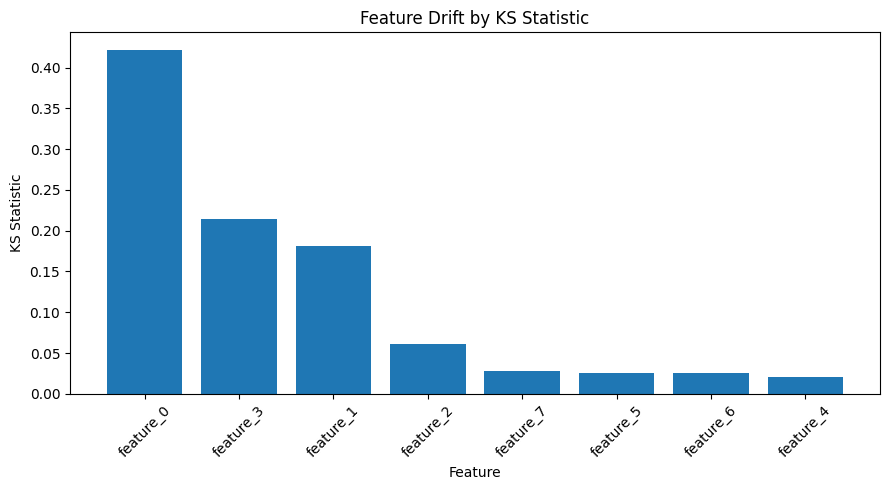

In [39]:
plot_data = (
    drifted_feature_drift
    .sort_values(
        "ks_statistic",
        ascending=False
    )
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    plot_data["feature"],
    plot_data["ks_statistic"]
)

plt.xlabel("Feature")
plt.ylabel("KS Statistic")
plt.title("Feature Drift by KS Statistic")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
drifted_metrics = score_batch(
    model,
    drifted_X,
    drifted_y
)

current_accuracy = (
    drifted_metrics["accuracy"]
)

current_confidence = (
    drifted_metrics[
        "confidence"
    ].mean()
)

current_positive_rate = (
    drifted_metrics[
        "predictions"
    ].mean()
)

print(
    f"Drifted accuracy: "
    f"{current_accuracy:.2%}"
)

print(
    f"Drifted confidence: "
    f"{current_confidence:.2%}"
)

print(
    f"Drifted positive rate: "
    f"{current_positive_rate:.2%}"
)

Drifted accuracy: 91.90%
Drifted confidence: 82.51%
Drifted positive rate: 45.90%


In [41]:
accuracy_drop = (
    reference_accuracy
    -
    current_accuracy
)

confidence_drop = (
    reference_confidence
    -
    current_confidence
)

prediction_rate_change = abs(
    current_positive_rate
    -
    reference_positive_rate
)

print(
    "Accuracy drop:",
    f"{accuracy_drop:.2%}"
)

print(
    "Confidence drop:",
    f"{confidence_drop:.2%}"
)

print(
    "Prediction-rate change:",
    f"{prediction_rate_change:.2%}"
)

Accuracy drop: 5.70%
Confidence drop: 9.42%
Prediction-rate change: 4.20%


In [42]:
def monitor_batch(
    reference_X,
    current_X,
    reference_metrics,
    current_metrics
):

    feature_results = detect_feature_drift(
        reference_X,
        current_X
    )

    drifted_features = (
        feature_results.loc[
            feature_results[
                "drift_detected"
            ],
            "feature"
        ]
        .tolist()
    )

    reference_accuracy = (
        reference_metrics.get(
            "accuracy"
        )
    )

    current_accuracy = (
        current_metrics.get(
            "accuracy"
        )
    )

    accuracy_drop = (
        reference_accuracy
        -
        current_accuracy
        if (
            reference_accuracy
            is not None
            and current_accuracy
            is not None
        )
        else None
    )

    reference_confidence = (
        reference_metrics[
            "confidence"
        ].mean()
    )

    current_confidence = (
        current_metrics[
            "confidence"
        ].mean()
    )

    confidence_drop = (
        reference_confidence
        -
        current_confidence
    )

    reference_rate = (
        reference_metrics[
            "predictions"
        ].mean()
    )

    current_rate = (
        current_metrics[
            "predictions"
        ].mean()
    )

    prediction_rate_change = abs(
        current_rate
        -
        reference_rate
    )

    alerts = []

    if drifted_features:
        alerts.append(
            "FEATURE_DRIFT"
        )

    if (
        accuracy_drop is not None
        and accuracy_drop
        > ACCURACY_DROP_LIMIT
    ):
        alerts.append(
            "PERFORMANCE_DRIFT"
        )

    if (
        confidence_drop
        > CONFIDENCE_DROP_LIMIT
    ):
        alerts.append(
            "CONFIDENCE_DRIFT"
        )

    if (
        prediction_rate_change
        > PREDICTION_RATE_CHANGE_LIMIT
    ):
        alerts.append(
            "PREDICTION_DRIFT"
        )

    return {
        "status":
            "DRIFT"
            if alerts
            else "HEALTHY",

        "alerts":
            alerts,

        "drifted_features":
            drifted_features,

        "accuracy_drop": (
            float(accuracy_drop)
            if accuracy_drop is not None
            else None
        ),

        "confidence_drop":
            float(confidence_drop),

        "prediction_rate_change":
            float(
                prediction_rate_change
            )
    }

In [43]:
healthy_report = monitor_batch(
    reference_X=X_reference,
    current_X=healthy_X,
    reference_metrics=reference_metrics,
    current_metrics=healthy_metrics
)

healthy_report

{'status': 'HEALTHY',
 'alerts': [],
 'drifted_features': [],
 'accuracy_drop': 0.013000000000000012,
 'confidence_drop': 0.013826666666666654,
 'prediction_rate_change': 0.0}

In [44]:
drift_report = monitor_batch(
    reference_X=X_reference,
    current_X=drifted_X,
    reference_metrics=reference_metrics,
    current_metrics=drifted_metrics
)

drift_report

{'status': 'DRIFT',
 'alerts': ['FEATURE_DRIFT', 'PERFORMANCE_DRIFT', 'CONFIDENCE_DRIFT'],
 'drifted_features': ['feature_0', 'feature_1', 'feature_3'],
 'accuracy_drop': 0.05699999999999994,
 'confidence_drop': 0.09419333333333324,
 'prediction_rate_change': 0.04199999999999998}

In [45]:
comparison = pd.DataFrame([
    {
        "environment":
            "Reference",

        "accuracy":
            reference_accuracy,

        "confidence":
            reference_confidence,

        "positive_rate":
            reference_positive_rate
    },

    {
        "environment":
            "Healthy Production",

        "accuracy":
            healthy_metrics[
                "accuracy"
            ],

        "confidence":
            healthy_metrics[
                "confidence"
            ].mean(),

        "positive_rate":
            healthy_metrics[
                "predictions"
            ].mean()
    },

    {
        "environment":
            "Drifted Production",

        "accuracy":
            current_accuracy,

        "confidence":
            current_confidence,

        "positive_rate":
            current_positive_rate
    }
])

comparison

,environment,accuracy,confidence,positive_rate
0,Reference,0.976,0.919327,0.501
1,Healthy Production,0.963,0.905500,0.501
2,Drifted Production,0.919,0.825133,0.459


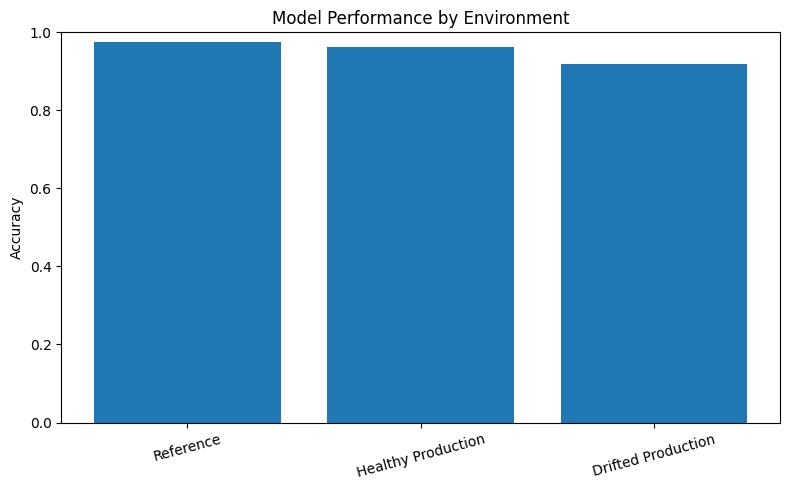

In [46]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison["environment"],
    comparison["accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Performance by Environment")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

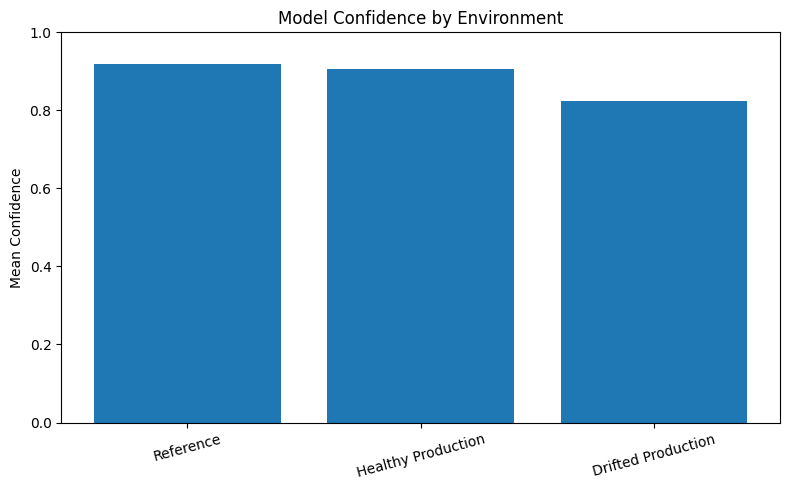

In [47]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison["environment"],
    comparison["confidence"]
)

plt.ylabel("Mean Confidence")
plt.title("Model Confidence by Environment")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [48]:
MODEL_PATH = (
    ARTIFACT_DIR
    / "production_model.joblib"
)

joblib.dump(
    model,
    MODEL_PATH
)

print(
    "Saved:",
    MODEL_PATH
)

Saved: drift_monitor_artifacts/production_model.joblib


In [49]:
REFERENCE_PATH = (
    ARTIFACT_DIR
    / "reference_profile.joblib"
)

reference_profile = {
    "features":
        FEATURES,

    "X_reference":
        X_reference,

    "accuracy":
        reference_accuracy,

    "confidence":
        reference_confidence,

    "positive_rate":
        reference_positive_rate
}

joblib.dump(
    reference_profile,
    REFERENCE_PATH
)

print(
    "Saved:",
    REFERENCE_PATH
)

Saved: drift_monitor_artifacts/reference_profile.joblib


In [50]:
REPORT_PATH = (
    ARTIFACT_DIR
    / "drift_report.json"
)

report = {
    "timestamp":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "model":
        "RandomForestClassifier",

    "reference_samples":
        len(X_reference),

    "production_samples":
        len(drifted_X),

    **drift_report
}

with open(
    REPORT_PATH,
    "w"
) as file:

    json.dump(
        report,
        file,
        indent=4
    )

print(
    "Saved:",
    REPORT_PATH
)

Saved: drift_monitor_artifacts/drift_report.json


In [51]:
FEATURE_REPORT_PATH = (
    ARTIFACT_DIR
    / "feature_drift.csv"
)

drifted_feature_drift.to_csv(
    FEATURE_REPORT_PATH,
    index=False
)

print(
    "Saved:",
    FEATURE_REPORT_PATH
)

Saved: drift_monitor_artifacts/feature_drift.csv


In [52]:
def smoke_test():

    # Dataset
    assert X.shape == (
        5000,
        8
    )

    assert (
        len(X_train)
        == 3000
    )

    assert (
        len(X_reference)
        == 1000
    )

    assert (
        len(X_production)
        == 1000
    )

    # Metrics
    assert (
        0
        <= reference_accuracy
        <= 1
    )

    assert np.all(
        (
            reference_metrics[
                "confidence"
            ]
            >= 0
        )
        &
        (
            reference_metrics[
                "confidence"
            ]
            <= 1
        )
    )

    # Reports
    assert healthy_report[
        "status"
    ] in {
        "HEALTHY",
        "DRIFT"
    }

    assert drift_report[
        "status"
    ] == "DRIFT"

    # Known injected drift
    detected = set(
        drift_report[
            "drifted_features"
        ]
    )

    assert "feature_0" in detected
    assert "feature_3" in detected

    # Artifacts
    assert MODEL_PATH.exists()
    assert REFERENCE_PATH.exists()
    assert REPORT_PATH.exists()
    assert FEATURE_REPORT_PATH.exists()

    # Reload verification
    loaded_model = joblib.load(
        MODEL_PATH
    )

    original_predictions = model.predict(
        X_reference
    )

    loaded_predictions = loaded_model.predict(
        X_reference
    )

    assert np.array_equal(
        original_predictions,
        loaded_predictions
    )

    print(
        "✅ Drift monitoring pipeline passed."
    )


smoke_test()

✅ Drift monitoring pipeline passed.
